# Import Prerequisites

In [1]:
#import statements

import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from tabulate import tabulate

warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [2]:
case_time = pd.read_csv('../districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [3]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [4]:
state = 'Rajasthan'
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
259,2020-04-26,Rajasthan,Ajmer,123,5,0
260,2020-04-26,Rajasthan,Alwar,7,4,1
261,2020-04-26,Rajasthan,Banswara,62,21,0
262,2020-04-26,Rajasthan,Barmer,2,1,0
263,2020-04-26,Rajasthan,Bharatpur,110,5,1
...,...,...,...,...,...,...
258394,2021-06-02,Rajasthan,Sawai Madhopur,10560,10246,56
258395,2021-06-02,Rajasthan,Sikar,30082,28257,322
258396,2021-06-02,Rajasthan,Sirohi,13522,13101,77
258397,2021-06-02,Rajasthan,Tonk,9227,8748,84


In [5]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [6]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [7]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [8]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2020
|| ===================================== ||


In [9]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2021
|| ===================================== ||


Trend of Active cases in Jaipur for the year 2020


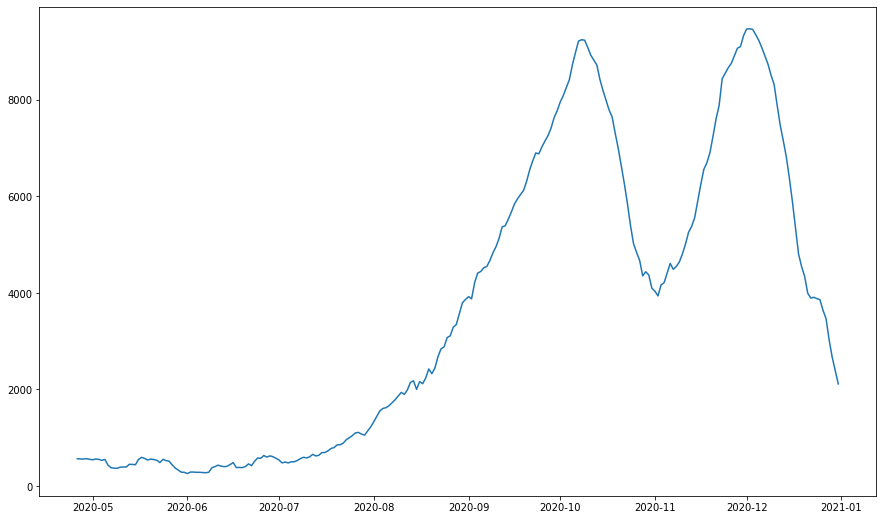

In [10]:
district = 'Jaipur'
pd.set_option('display.max_rows',466)
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of COVID-19 cases in Jaipur for the year 2021



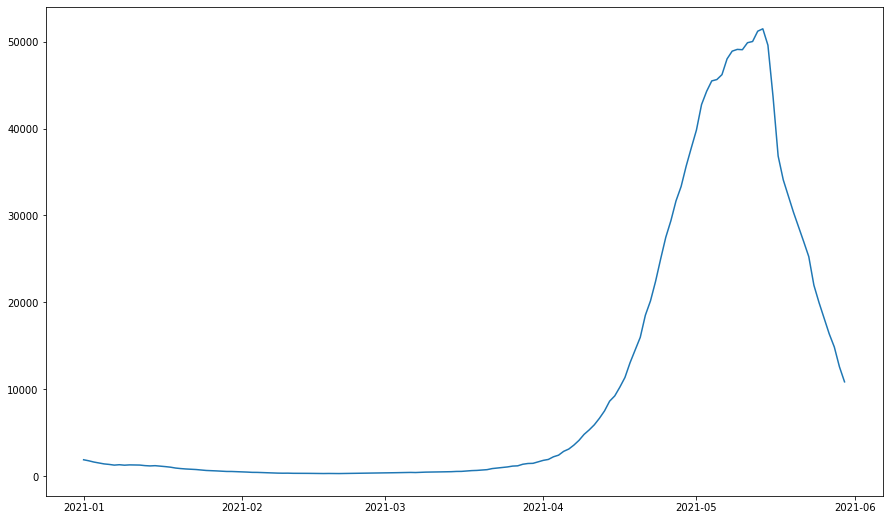

In [11]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of COVID-19 cases in",district,"for the year 2021\n")
plt.plot(bang_data_21)

In [12]:
quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Jaipur
            Active
Date              
2020-04-26     565
2020-04-27     562
2020-04-28     559
2020-04-29     568
2020-04-30     554
2020-05-01     544
2020-05-02     561
2020-05-03     553
2020-05-04     532
2020-05-05     551
2020-05-06     435
2020-05-07     381
2020-05-08     371
2020-05-09     368
2020-05-10     390
2020-05-11     395
2020-05-12     395
2020-05-13     450
2020-05-14     449
2020-05-15     442
2020-05-16     551
2020-05-17     594
2020-05-18     572
2020-05-19     540
2020-05-20     558
2020-05-21     549
2020-05-22     534
2020-05-23     486
2020-05-24     552
2020-05-25     528
2020-05-26     516
2020-05-27     441
2020-05-28     374
2020-05-29     330
2020-05-30     288
2020-05-31     285
2020-06-01     259
2020-06-02     290
2020-06-03     290
2020-06-04     285
2020-06-05     285
2020-06-06     281
2020-06-07     276
2020-06-08     286
2020-06-09     378
2020-06-10     402
2020-06-11     433
2020-06-12     413
2020-06-13     402
2020-0

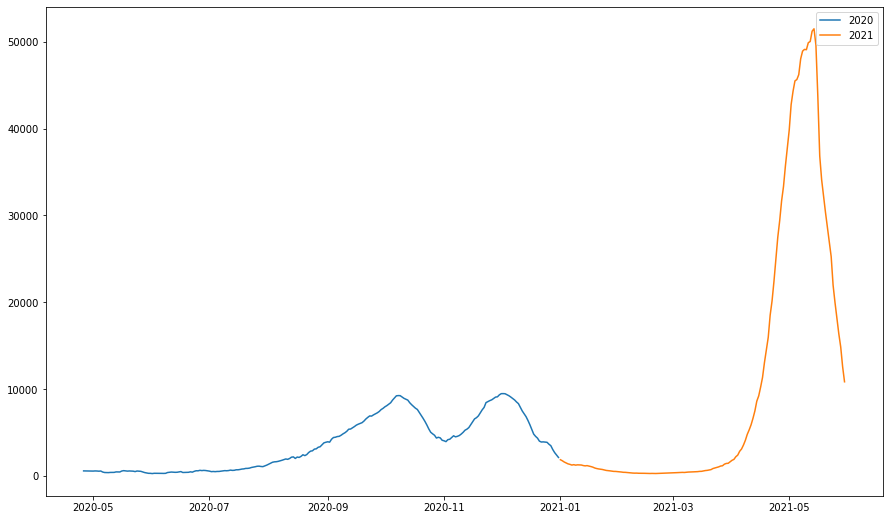

In [13]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# RNN Implementation

In [14]:

# univariate lstm example
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten


In [15]:
# preparing independent and dependent features
def prepare_data(timeseries_data, n_features):
    X, y =[],[]
    for i in range(len(timeseries_data)):
        # find the end of this pattern
        end_ix = i + n_features
        # check if we are beyond the sequence
        if end_ix > len(timeseries_data)-1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [16]:
n_steps = 7  
n_features = 1
def prep_data(mod_data):
    # define input sequence
    timeseries_data = mod_data.values
    # choose a number of time steps
    # split into samples
    X, y = prepare_data(timeseries_data, n_steps)
    return X,y

In [17]:
def train_model(X,y):
    # reshape from [samples, timesteps] into [samples, timesteps, features]
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    # define model
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    # fit model
    model.fit(X, y, epochs=300, verbose=1)
    print(model.summary())
    
    return model


# Forecast over 1st test interval

In [18]:
# demonstrate prediction for next 10 days
def pred_nxt(days,dta):
    X, y = prep_data(dta)
    model = train_model(X,y)
    x_input = np.array(y[-8:])
    temp_input=list(x_input)
    lst_output=[]
    i=0
    while(i<days):

        if(len(temp_input)>3):
            x_input=np.array(temp_input[1:])
            print("{} day input {}".format(i,x_input))
            x_input = x_input.reshape((1, n_steps, n_features))
            yhat = model.predict(x_input, verbose=0)
            print("{} day output {}".format(i,yhat))
            temp_input.append(yhat[0][0])
            temp_input=temp_input[1:]
            #print(temp_input)
            lst_output.append(yhat[0][0])
            i=i+1
        else:
            print(x_input)
            x_input = x_input.reshape((1, n_steps, n_features))
            yhat = model.predict(x_input, verbose=0)
            print(yhat[0])
            temp_input.append(yhat[0][0])
            lst_output.append(yhat[0][0])
            i=i+1


    return (lst_output)

In [19]:
def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [20]:
rmse_for_tab = []
for i in range(1,15):
    period = int(i)
    ress = pred_nxt(i,bang_data)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Use tf.cast instead.
Instructions for updating:
Use tf.cast instead.
Epoch 1/300
243/243 [==============================] - 1s 6ms/sample - loss: 22157789.5473
Epoch 2/300
243/243 [==============================] - 0s 308us/sample - loss: 15580350.4342
Epoch 3/300
243/243 [==============================] - 0s 312us/sample - loss: 5333842.6255
Epoch 4/300
243/243 [==============================] - 0s 320us/sample - loss: 1451641.3580
Epoch 5/300
243/243 [==============================] - 0s 320us/sample - loss: 802830.6749
Epoch 6/300
243/243 [==============================] - 0s 332us/sample - loss: 1660576.4753
Epoch 7/300
243/243 [==============================] - 0s 447us/sample - loss: 1316877.5545
Epoch 8/300
243/243 [==============================] - 0s 304us/sample - loss: 691987.9639
Epoch 9/300
243/243 [==============================] - 0s 341us/sample - loss: 717568.1595
Epoch 1

243/243 [==============================] - 0s 394us/sample - loss: 361314.2159
Epoch 81/300
243/243 [==============================] - 0s 386us/sample - loss: 379769.3857
Epoch 82/300
243/243 [==============================] - 0s 341us/sample - loss: 372768.4104
Epoch 83/300
243/243 [==============================] - 0s 332us/sample - loss: 353005.1947
Epoch 84/300
243/243 [==============================] - 0s 353us/sample - loss: 389177.6053
Epoch 85/300
243/243 [==============================] - 0s 378us/sample - loss: 399486.8850
Epoch 86/300
243/243 [==============================] - 0s 328us/sample - loss: 326968.0896
Epoch 87/300
243/243 [==============================] - 0s 386us/sample - loss: 361601.2275
Epoch 88/300
243/243 [==============================] - 0s 431us/sample - loss: 404778.3889
Epoch 89/300
243/243 [==============================] - 0s 398us/sample - loss: 433815.6878
Epoch 90/300
243/243 [==============================] - 0s 402us/sample - loss: 775686.2845
E

243/243 [==============================] - 0s 324us/sample - loss: 40320.0356
Epoch 169/300
243/243 [==============================] - 0s 390us/sample - loss: 44969.5161
Epoch 170/300
243/243 [==============================] - 0s 365us/sample - loss: 51826.1374
Epoch 171/300
243/243 [==============================] - 0s 324us/sample - loss: 45244.0646
Epoch 172/300
243/243 [==============================] - 0s 423us/sample - loss: 44411.7078
Epoch 173/300
243/243 [==============================] - 0s 427us/sample - loss: 35050.8273
Epoch 174/300
243/243 [==============================] - 0s 402us/sample - loss: 37200.0881
Epoch 175/300
243/243 [==============================] - 0s 419us/sample - loss: 33716.4626
Epoch 176/300
243/243 [==============================] - 0s 365us/sample - loss: 35785.8496
Epoch 177/300
243/243 [==============================] - 0s 341us/sample - loss: 37720.3446
Epoch 178/300
243/243 [==============================] - 0s 386us/sample - loss: 38670.0623
Ep

243/243 [==============================] - 0s 320us/sample - loss: 51191.9934
Epoch 257/300
243/243 [==============================] - 0s 308us/sample - loss: 46482.7719
Epoch 258/300
243/243 [==============================] - 0s 337us/sample - loss: 45953.8936
Epoch 259/300
243/243 [==============================] - 0s 373us/sample - loss: 42536.7063
Epoch 260/300
243/243 [==============================] - 0s 341us/sample - loss: 41599.8910
Epoch 261/300
243/243 [==============================] - 0s 332us/sample - loss: 40293.0479
Epoch 262/300
243/243 [==============================] - 0s 349us/sample - loss: 40376.3689
Epoch 263/300
243/243 [==============================] - 0s 332us/sample - loss: 40705.2192
Epoch 264/300
243/243 [==============================] - 0s 332us/sample - loss: 40157.4325
Epoch 265/300
243/243 [==============================] - 0s 296us/sample - loss: 40626.8766
Epoch 266/300
243/243 [==============================] - 0s 402us/sample - loss: 43084.5550
Ep

243/243 [==============================] - 0s 287us/sample - loss: 500934.5653
Epoch 37/300
243/243 [==============================] - 0s 328us/sample - loss: 486811.6772
Epoch 38/300
243/243 [==============================] - 0s 267us/sample - loss: 487006.7451
Epoch 39/300
243/243 [==============================] - 0s 271us/sample - loss: 490707.7954
Epoch 40/300
243/243 [==============================] - 0s 263us/sample - loss: 488584.8970
Epoch 41/300
243/243 [==============================] - 0s 267us/sample - loss: 499540.4124
Epoch 42/300
243/243 [==============================] - 0s 296us/sample - loss: 494643.9417
Epoch 43/300
243/243 [==============================] - 0s 296us/sample - loss: 492140.6229
Epoch 44/300
243/243 [==============================] - 0s 304us/sample - loss: 490766.2252
Epoch 45/300
243/243 [==============================] - 0s 263us/sample - loss: 473038.6849
Epoch 46/300
243/243 [==============================] - 0s 263us/sample - loss: 457669.4832
E

...

243/243 [==============================] - 0s 353us/sample - loss: 66284.6560
Epoch 272/300
243/243 [==============================] - 0s 345us/sample - loss: 110870.6413
Epoch 273/300
243/243 [==============================] - 0s 332us/sample - loss: 153875.5846
Epoch 274/300
243/243 [==============================] - 0s 332us/sample - loss: 147533.1452
Epoch 275/300
243/243 [==============================] - 0s 332us/sample - loss: 127058.7600
Epoch 276/300
243/243 [==============================] - 0s 308us/sample - loss: 92091.4698
Epoch 277/300
243/243 [==============================] - 0s 308us/sample - loss: 56873.3595
Epoch 278/300
243/243 [==============================] - 0s 320us/sample - loss: 58191.9854
Epoch 279/300
243/243 [==============================] - 0s 332us/sample - loss: 53058.3383
Epoch 280/300
243/243 [==============================] - 0s 337us/sample - loss: 43399.2595
Epoch 281/300
243/243 [==============================] - 0s 324us/sample - loss: 33693.445

243/243 [==============================] - 0s 308us/sample - loss: 171100.0342
Epoch 36/300
243/243 [==============================] - 0s 308us/sample - loss: 179116.7169
Epoch 37/300
243/243 [==============================] - 0s 304us/sample - loss: 190073.4842
Epoch 38/300
243/243 [==============================] - 0s 308us/sample - loss: 182139.9412
Epoch 39/300
243/243 [==============================] - 0s 312us/sample - loss: 175391.4308
Epoch 40/300
243/243 [==============================] - 0s 308us/sample - loss: 162199.8629
Epoch 41/300
243/243 [==============================] - 0s 312us/sample - loss: 131872.5611
Epoch 42/300
243/243 [==============================] - 0s 320us/sample - loss: 216275.1621
Epoch 43/300
243/243 [==============================] - 0s 316us/sample - loss: 142691.7632
Epoch 44/300
243/243 [==============================] - 0s 308us/sample - loss: 158871.6620
Epoch 45/300
243/243 [==============================] - 0s 312us/sample - loss: 150665.0740
E

243/243 [==============================] - 0s 378us/sample - loss: 114230.1617
Epoch 124/300
243/243 [==============================] - 0s 394us/sample - loss: 115602.7362
Epoch 125/300
243/243 [==============================] - 0s 312us/sample - loss: 290051.6188
Epoch 126/300
243/243 [==============================] - 0s 394us/sample - loss: 245141.5611
Epoch 127/300
243/243 [==============================] - 0s 419us/sample - loss: 305912.2284
Epoch 128/300
243/243 [==============================] - 0s 406us/sample - loss: 272012.3350
Epoch 129/300
243/243 [==============================] - 0s 386us/sample - loss: 205765.8426
Epoch 130/300
243/243 [==============================] - 0s 607us/sample - loss: 115990.1772 - loss: 144245.
Epoch 131/300
243/243 [==============================] - 0s 517us/sample - loss: 120287.2420
Epoch 132/300
243/243 [==============================] - 0s 476us/sample - loss: 241035.9048
Epoch 133/300
243/243 [==============================] - 0s 488us/sa

243/243 [==============================] - 0s 349us/sample - loss: 111545.4092
Epoch 212/300
243/243 [==============================] - 0s 353us/sample - loss: 98533.5665
Epoch 213/300
243/243 [==============================] - 0s 361us/sample - loss: 98569.8751
Epoch 214/300
243/243 [==============================] - 0s 332us/sample - loss: 103086.1466
Epoch 215/300
243/243 [==============================] - 0s 345us/sample - loss: 107355.8661
Epoch 216/300
243/243 [==============================] - 0s 394us/sample - loss: 107930.6255
Epoch 217/300
243/243 [==============================] - 0s 451us/sample - loss: 135831.2524
Epoch 218/300
243/243 [==============================] - 0s 353us/sample - loss: 119088.4156
Epoch 219/300
243/243 [==============================] - 0s 349us/sample - loss: 90136.8752
Epoch 220/300
243/243 [==============================] - 0s 435us/sample - loss: 90785.5035
Epoch 221/300
243/243 [==============================] - 0s 316us/sample - loss: 104596.

243/243 [==============================] - 0s 316us/sample - loss: 60586.5974
Epoch 300/300
243/243 [==============================] - 0s 394us/sample - loss: 58756.4397
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_26 (LSTM)               (None, 7, 50)             10400     
_________________________________________________________________
lstm_27 (LSTM)               (None, 50)                20200     
_________________________________________________________________
dense_13 (Dense)             (None, 1)                 51        
Total params: 30,651
Trainable params: 30,651
Non-trainable params: 0
_________________________________________________________________
None
0 day input [[3859]
 [3640]
 [3466]
 [3029]
 [2671]
 [2396]
 [2114]]
0 day output [[2271.5977]]
1 day input [array([3640]) array([3466]) array([3029]) array([2671]) array([2396])
 array([2114]) 2271.5977]
1 day output [[1825.98

In [21]:
ress = pred_nxt(10,bang_data)

Epoch 1/300
243/243 [==============================] - 5s 21ms/sample - loss: 21282615.6996
Epoch 2/300
243/243 [==============================] - 0s 394us/sample - loss: 17898805.0041
Epoch 3/300
243/243 [==============================] - 0s 386us/sample - loss: 13641912.3992
Epoch 4/300
243/243 [==============================] - 0s 394us/sample - loss: 5887327.4475
Epoch 5/300
243/243 [==============================] - 0s 390us/sample - loss: 1451402.9841
Epoch 6/300
243/243 [==============================] - 0s 378us/sample - loss: 565925.2510
Epoch 7/300
243/243 [==============================] - 0s 386us/sample - loss: 597280.0251
Epoch 8/300
243/243 [==============================] - 0s 398us/sample - loss: 477905.5022
Epoch 9/300
243/243 [==============================] - 0s 390us/sample - loss: 392196.0276
Epoch 10/300
243/243 [==============================] - 0s 382us/sample - loss: 329282.7141
Epoch 11/300
243/243 [==============================] - 0s 386us/sample - loss: 30

243/243 [==============================] - 0s 382us/sample - loss: 650565.3306
Epoch 91/300
243/243 [==============================] - 0s 378us/sample - loss: 572017.1250
Epoch 92/300
243/243 [==============================] - 0s 390us/sample - loss: 584355.6872
Epoch 93/300
243/243 [==============================] - 0s 394us/sample - loss: 584982.1921
Epoch 94/300
243/243 [==============================] - 0s 373us/sample - loss: 574724.2479
Epoch 95/300
243/243 [==============================] - 0s 361us/sample - loss: 545447.9483
Epoch 96/300
243/243 [==============================] - 0s 361us/sample - loss: 491842.1816
Epoch 97/300
243/243 [==============================] - 0s 353us/sample - loss: 424526.7109
Epoch 98/300
243/243 [==============================] - 0s 361us/sample - loss: 426407.0332
Epoch 99/300
243/243 [==============================] - 0s 382us/sample - loss: 485544.9334
Epoch 100/300
243/243 [==============================] - 0s 373us/sample - loss: 527795.1601


243/243 [==============================] - 0s 378us/sample - loss: 467117.1035
Epoch 179/300
243/243 [==============================] - 0s 369us/sample - loss: 395388.0032
Epoch 180/300
243/243 [==============================] - 0s 369us/sample - loss: 357208.4928
Epoch 181/300
243/243 [==============================] - 0s 349us/sample - loss: 401258.4385
Epoch 182/300
243/243 [==============================] - 0s 345us/sample - loss: 394962.8900
Epoch 183/300
243/243 [==============================] - 0s 357us/sample - loss: 391760.6121
Epoch 184/300
243/243 [==============================] - 0s 373us/sample - loss: 361502.9337
Epoch 185/300
243/243 [==============================] - 0s 373us/sample - loss: 344905.8783
Epoch 186/300
243/243 [==============================] - 0s 373us/sample - loss: 327241.7266
Epoch 187/300
243/243 [==============================] - 0s 373us/sample - loss: 308301.6623
Epoch 188/300
243/243 [==============================] - 0s 361us/sample - loss: 261

243/243 [==============================] - 0s 456us/sample - loss: 50556.1713
Epoch 267/300
243/243 [==============================] - 0s 497us/sample - loss: 44166.8986
Epoch 268/300
243/243 [==============================] - 0s 460us/sample - loss: 43464.7950
Epoch 269/300
243/243 [==============================] - 0s 669us/sample - loss: 53822.4489
Epoch 270/300
243/243 [==============================] - 0s 702us/sample - loss: 50420.8560
Epoch 271/300
243/243 [==============================] - 0s 497us/sample - loss: 48078.9956
Epoch 272/300
243/243 [==============================] - 0s 456us/sample - loss: 52582.9943
Epoch 273/300
243/243 [==============================] - 0s 501us/sample - loss: 50702.5548
Epoch 274/300
243/243 [==============================] - 0s 509us/sample - loss: 49391.4719
Epoch 275/300
243/243 [==============================] - 0s 439us/sample - loss: 61406.4267
Epoch 276/300
243/243 [==============================] - 0s 369us/sample - loss: 59305.1212
Ep

Forecast of trend of growth of COVID-19 for the 1st test interval
               Forecast  Daily forecast  Confidence interval  Actual  Daily
Date                                                                       
2021-01-01  1763.860596            -351            94.272420    1854   -260
2021-01-02  1522.886475            -241            91.648550    1737   -117
2021-01-03  1294.566528            -228            81.395427    1592   -145
2021-01-04  1114.441284            -180            91.677310    1488   -104
2021-01-05   927.257080            -187            59.034010    1377   -111
2021-01-06   762.901611            -165            41.763042    1318    -59
2021-01-07   642.590027            -120            72.001847    1237    -81
2021-01-08   547.812744             -95            69.607443    1283     46
2021-01-09   449.672119             -98            84.366761    1229    -54
2021-01-10   366.144409             -83            86.509190    1264     35


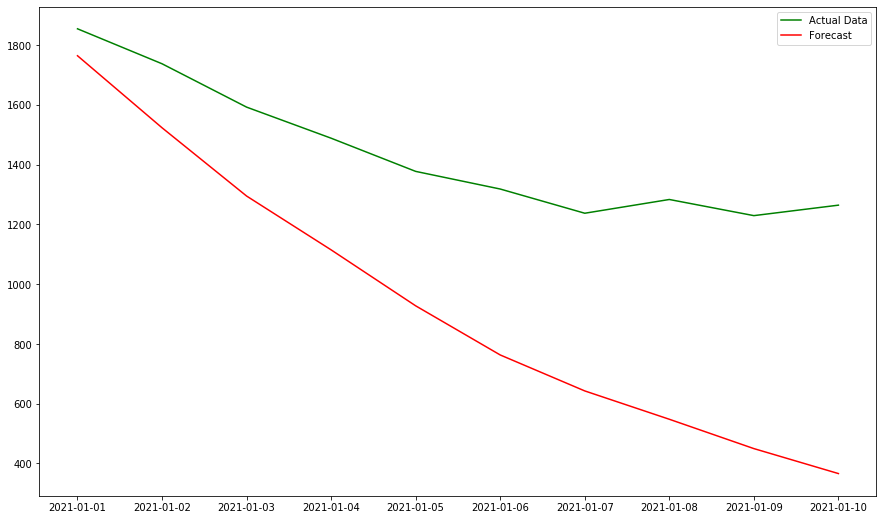

In [22]:
dt = bang_data.index[-1]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step

tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress

print("Forecast of trend of growth of COVID-19 for the 1st test interval")
daily = []
daily.append(int(ress[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab[:len(ress)]
tst['Actual'] = bang_data_21.values[:len(ress)]
cum = bang_data_21.values
daily = []
daily.append(int(cum[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(cum[i])-int(cum[i-1]))
tst['Daily'] = daily
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(tst['Actual'],color='green')
plt.plot(tst['Forecast'],color='red')
plt.legend(['Actual Data','Forecast'])

In [23]:
all_data = pd.concat([bang_data,bang_data_21])

In [24]:
dayss = 9
trdata = all_data[:-dayss]
tsdata = all_data[-dayss:]
ress = pred_nxt(dayss,trdata)

dt = trdata.index[-1]
end = dt + datetime.timedelta(days=dayss)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
cum = ress
dates = dtframe
daily = []
daily.append(cum[0]-bang_data[-1:].values)
data = []
for i in range(1,len(cum)):
    dd = []
    daily.append(cum[i]-cum[i-1])
    dts = tsdata.values[i] - tsdata.values[i-1]
    dd = [dates[i],int(daily[i]),int(cum[i]),rmse_for_tab[i],dts,tsdata.values[i]]
    data.append(dd)


Epoch 1/300
384/384 [==============================] - 4s 12ms/sample - loss: 53984841.5000
Epoch 2/300
384/384 [==============================] - 0s 356us/sample - loss: 10596277.9896
Epoch 3/300
384/384 [==============================] - 0s 351us/sample - loss: 9976701.5104
Epoch 4/300
384/384 [==============================] - 0s 345us/sample - loss: 8580634.9792
Epoch 5/300
384/384 [==============================] - 0s 358us/sample - loss: 4963014.4167
Epoch 6/300
384/384 [==============================] - 0s 353us/sample - loss: 5893120.5365
Epoch 7/300
384/384 [==============================] - 0s 358us/sample - loss: 4869256.4740
Epoch 8/300
384/384 [==============================] - 0s 395us/sample - loss: 4471004.0521
Epoch 9/300
384/384 [==============================] - 0s 361us/sample - loss: 3435642.8542
Epoch 10/300
384/384 [==============================] - 0s 356us/sample - loss: 8378477.7760
Epoch 11/300
384/384 [==============================] - 0s 371us/sample - loss

384/384 [==============================] - 0s 335us/sample - loss: 4555892.7865
Epoch 89/300
384/384 [==============================] - 0s 335us/sample - loss: 5860492.3229
Epoch 90/300
384/384 [==============================] - 0s 371us/sample - loss: 9198578.8542
Epoch 91/300
384/384 [==============================] - 0s 351us/sample - loss: 6862184.5208
Epoch 92/300
384/384 [==============================] - 0s 348us/sample - loss: 5115689.7188
Epoch 93/300
384/384 [==============================] - 0s 379us/sample - loss: 4420689.1849
Epoch 94/300
384/384 [==============================] - 0s 444us/sample - loss: 10765829.6146
Epoch 95/300
384/384 [==============================] - 0s 371us/sample - loss: 5059911.3750
Epoch 96/300
384/384 [==============================] - 0s 335us/sample - loss: 4632899.0156
Epoch 97/300
384/384 [==============================] - 0s 314us/sample - loss: 4208394.5573
Epoch 98/300
384/384 [==============================] - 0s 322us/sample - loss: 37

384/384 [==============================] - 0s 353us/sample - loss: 1734208.9531
Epoch 175/300
384/384 [==============================] - 0s 348us/sample - loss: 1888568.4176
Epoch 176/300
384/384 [==============================] - 0s 348us/sample - loss: 1571722.4922
Epoch 177/300
384/384 [==============================] - 0s 343us/sample - loss: 1557831.7441
Epoch 178/300
384/384 [==============================] - 0s 343us/sample - loss: 1405714.4635
Epoch 179/300
384/384 [==============================] - 0s 351us/sample - loss: 1260313.5592
Epoch 180/300
384/384 [==============================] - 0s 345us/sample - loss: 1464688.6562
Epoch 181/300
384/384 [==============================] - 0s 348us/sample - loss: 1427056.7383
Epoch 182/300
384/384 [==============================] - 0s 340us/sample - loss: 1227992.8555
Epoch 183/300
384/384 [==============================] - 0s 348us/sample - loss: 1287274.5677
Epoch 184/300
384/384 [==============================] - 0s 340us/sample -

384/384 [==============================] - 0s 338us/sample - loss: 796737.8005
Epoch 262/300
384/384 [==============================] - 0s 403us/sample - loss: 672293.7155
Epoch 263/300
384/384 [==============================] - 0s 340us/sample - loss: 964897.7428
Epoch 264/300
384/384 [==============================] - 0s 338us/sample - loss: 904522.8532
Epoch 265/300
384/384 [==============================] - 0s 340us/sample - loss: 804248.7324
Epoch 266/300
384/384 [==============================] - 0s 340us/sample - loss: 767391.7773
Epoch 267/300
384/384 [==============================] - 0s 338us/sample - loss: 736652.9808
Epoch 268/300
384/384 [==============================] - 0s 345us/sample - loss: 1319880.0417
Epoch 269/300
384/384 [==============================] - 0s 345us/sample - loss: 909466.8883
Epoch 270/300
384/384 [==============================] - 0s 345us/sample - loss: 1291138.3555
Epoch 271/300
384/384 [==============================] - 0s 348us/sample - loss: 8

Forecast of trend of growth of COVID-19 for the 2nd test interval
Date          Daily    Cumulative    Confidence Interval    Daily    Cumulative
----------  -------  ------------  ---------------------  -------  ------------
2021-05-22    -1139         24608                91.6485    -1737         25246
2021-05-23    -1635         22973                81.3954    -3285         21961
2021-05-24    -1684         21289                91.6773    -1994         19967
2021-05-25    -1294         19994                59.034     -1824         18143
2021-05-26    -1384         18610                41.763     -1785         16358
2021-05-27    -1259         17350                72.0018    -1519         14839
2021-05-28    -1115         16235                69.6074    -2271         12568
2021-05-29    -1099         15136                84.3668    -1738         10830


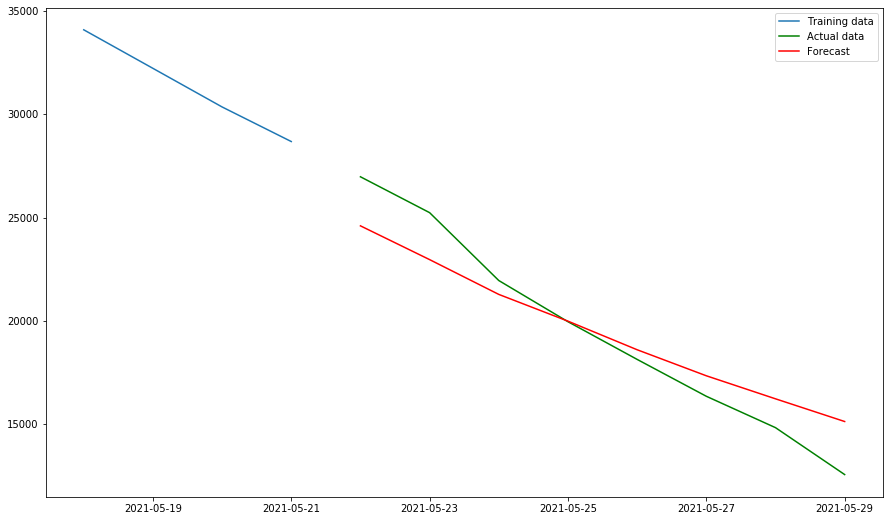

In [25]:
print("Forecast of trend of growth of COVID-19 for the 2nd test interval")
print(tabulate(data,headers=['Date','Daily','Cumulative','Confidence Interval','Daily','Cumulative']))
cum = [sub[2] for sub in data]
dts = [sub[0] for sub in data]
plt.plot(trdata[-int(dayss/2):])
plt.plot(tsdata[:len(cum)],color='green')
plt.plot(dts,cum,color = 'red')
plt.legend(['Training data','Actual data','Forecast'])

# Future forecast

In [26]:
all_data = pd.concat([bang_data,bang_data_21])
ress = pred_nxt(8,all_data)

Epoch 1/300
393/393 [==============================] - 5s 12ms/sample - loss: 149334749.4758
Epoch 2/300
393/393 [==============================] - 0s 409us/sample - loss: 141235620.3155
Epoch 3/300
393/393 [==============================] - 0s 358us/sample - loss: 133796938.1031
Epoch 4/300
393/393 [==============================] - 0s 419us/sample - loss: 130033920.1934
Epoch 5/300
393/393 [==============================] - 0s 353us/sample - loss: 82001823.5725
Epoch 6/300
393/393 [==============================] - 0s 332us/sample - loss: 16238443.3527
Epoch 7/300
393/393 [==============================] - 0s 409us/sample - loss: 8801262.1209
Epoch 8/300
393/393 [==============================] - 0s 365us/sample - loss: 6731484.9962
Epoch 9/300
393/393 [==============================] - 0s 343us/sample - loss: 7474873.6527
Epoch 10/300
393/393 [==============================] - 0s 335us/sample - loss: 7898419.3817
Epoch 11/300
393/393 [==============================] - 0s 338us/sampl

393/393 [==============================] - 0s 338us/sample - loss: 11627118.7277
Epoch 89/300
393/393 [==============================] - 0s 340us/sample - loss: 12348277.3842
Epoch 90/300
393/393 [==============================] - 0s 325us/sample - loss: 12960609.2118
Epoch 91/300
393/393 [==============================] - 0s 436us/sample - loss: 12656234.8906
Epoch 92/300
393/393 [==============================] - 0s 376us/sample - loss: 12593443.2780
Epoch 93/300
393/393 [==============================] - 0s 358us/sample - loss: 11620206.0763
Epoch 94/300
393/393 [==============================] - 0s 368us/sample - loss: 13439056.1660
Epoch 95/300
393/393 [==============================] - 0s 365us/sample - loss: 12060049.4148
Epoch 96/300
393/393 [==============================] - 0s 373us/sample - loss: 11167184.1730
Epoch 97/300
393/393 [==============================] - 0s 360us/sample - loss: 10666458.4402
Epoch 98/300
393/393 [==============================] - 0s 340us/sample -

393/393 [==============================] - 0s 335us/sample - loss: 9271097.6438
Epoch 175/300
393/393 [==============================] - 0s 325us/sample - loss: 8975393.2179
Epoch 176/300
393/393 [==============================] - 0s 343us/sample - loss: 8997802.5935
Epoch 177/300
393/393 [==============================] - 0s 325us/sample - loss: 8754963.4478
Epoch 178/300
393/393 [==============================] - 0s 360us/sample - loss: 8790405.1493
Epoch 179/300
393/393 [==============================] - 0s 327us/sample - loss: 8529652.2290
Epoch 180/300
393/393 [==============================] - 0s 327us/sample - loss: 8291065.4821
Epoch 181/300
393/393 [==============================] - 0s 335us/sample - loss: 8206299.4618
Epoch 182/300
393/393 [==============================] - 0s 327us/sample - loss: 8070100.0865
Epoch 183/300
393/393 [==============================] - 0s 327us/sample - loss: 7938680.2646
Epoch 184/300
393/393 [==============================] - 0s 340us/sample -

393/393 [==============================] - 0s 368us/sample - loss: 1809963.3336
Epoch 262/300
393/393 [==============================] - 0s 376us/sample - loss: 1307871.9736
Epoch 263/300
393/393 [==============================] - 0s 398us/sample - loss: 1418832.6569
Epoch 264/300
393/393 [==============================] - 0s 368us/sample - loss: 1355979.0369
Epoch 265/300
393/393 [==============================] - 0s 340us/sample - loss: 1366052.5152
Epoch 266/300
393/393 [==============================] - 0s 335us/sample - loss: 1715848.2603
Epoch 267/300
393/393 [==============================] - 0s 358us/sample - loss: 1345894.7641
Epoch 268/300
393/393 [==============================] - 0s 330us/sample - loss: 1422636.0347
Epoch 269/300
393/393 [==============================] - 0s 355us/sample - loss: 1253229.5992
Epoch 270/300
393/393 [==============================] - 0s 358us/sample - loss: 1448139.8481
Epoch 271/300
393/393 [==============================] - 0s 348us/sample -

Future forecast of COVID-19
                Forecast  Daily forecast  Confidence interval
Date                                                         
2021-05-30  11355.462891             525            94.272420
2021-05-31  10362.467773            -993            91.648550
2021-06-01   9740.677734            -622            81.395427
2021-06-02   7910.490723           -1830            91.677310
2021-06-03   8764.666016             854            59.034010
2021-06-04  10820.002930            2056            41.763042
2021-06-05   7505.119629           -3315            72.001847
2021-06-06   6873.880371            -632            69.607443


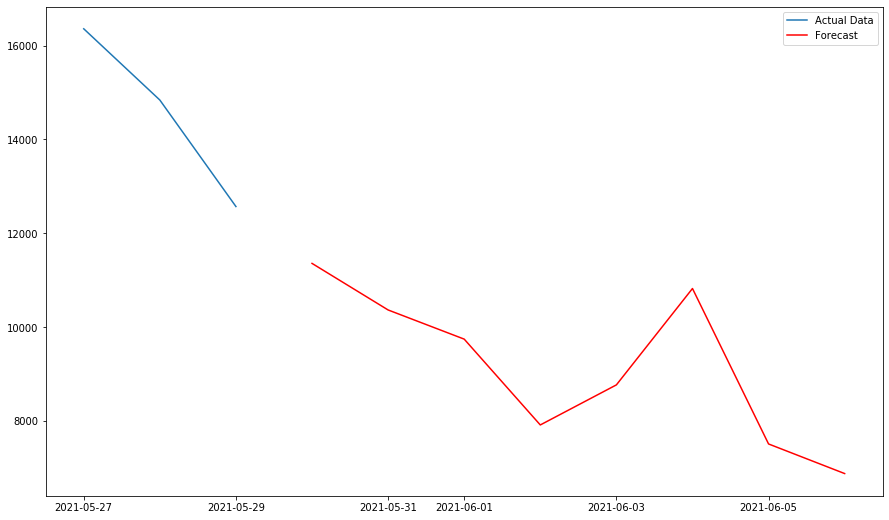

In [27]:
dt = all_data.index[-2]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step

print("Future forecast of COVID-19")
tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress

daily = []
daily.append(int(ress[0])-int(all_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab[:len(ress)]
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(all_data[-int(len(ress)/2):-1])
plt.plot(tst['Forecast'],color='red')
plt.legend(['Actual Data','Forecast'])